In [6]:
# ==========================================================
# Final model
# Using a combitnation of all the other models 
# and adding data fusion between embedded system and historical data:
# ==========================================================



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path.cwd()

print("Imports loaded")

Imports loaded


In [7]:
# ==========================================================
# RANDOM GENERATOR
# ==========================================================

rng = np.random.default_rng(42)

# ==========================================================
# HISTORICAL DATA
# ==========================================================

INPUT_FILE = BASE_DIR / "ATHENRY_30_DAYS.csv"

history = pd.read_csv(INPUT_FILE ,encoding="latin1")
history = history.drop(columns=["Date"])



#What if simulation
print("\nAvailable columns:")
for i, col in enumerate(history.columns, 1):
    print(f" {i}. {col}")

while True:
    col_input = input("\nEnter column name (or leave blank to finish): ").strip()
    if col_input == "":
        print("Done.")
        break

    if col_input not in history.columns:
        print(f"Column '{col_input}' not found. Please try again.")
        continue

    direction = input(f"Increase or decrease '{col_input}'? (i/d): ").strip().lower()
    if direction not in ("i", "d"):
        print("Invalid choice. Please enter 'i' for increase or 'd' for decrease.")
        continue

    try:
        percentage = float(input(f"Enter percentage for '{col_input}' (e.g. 40 for 40%): "))
    except ValueError:
        print("Invalid number. Please try again.")
        continue

    if direction == "i":
        multiplier = 1 + percentage / 100
        action = "increased"
    else:
        multiplier = 1 - percentage / 100
        action = "decreased"

    history[col_input] = history[col_input] * multiplier
    print(f"\n'{col_input}' {action} by {percentage}% (multiplier: {multiplier})\n")
    print(history[col_input])

# ==========================================================
# PARAMETERS
# ==========================================================

WEIGHTS = {  
    "gust": 0.45,
    "mean_wind": 0.25,
    "rain": 0.20,
    "soil": 0.05,
    "pressure": 0.03,
    "temp": 0.01,
    "evap": 0.01,
}

THRESHOLDS = {
    "gust": 100,
    "mean_wind": 55,
    "rain_3d": 80,
    "rain_7d": 160,
    "soil": 30,
    "pressure_drop": 35,
    "temp_range": 18,
    "net_moisture": 120,
}




Available columns:
 1. Max Gust (kt)
 2. Mean Wind Speed (kt)
 3. Rain (mm)
 4. Soil Moisture Deficit - Moderate (mm)
 5. Mean Pressure (hPa)
 6. Max Temp (C)
 7. Min Temp (C)
 8. Evaporation (mm)
Done.


In [8]:
# ==========================================================
# Calculating spike factor
# ==========================================================


INPUT_FILE = BASE_DIR / "thingspeakfeed.csv"

feed = pd.read_csv(INPUT_FILE ,encoding="latin1")

historical_ratio = history["Max Gust (kt)"].mean() / history["Mean Wind Speed (kt)"].mean()
embedded_ratio = feed["Max minute gust (kt)"].max() / feed["Mean Wind (kt)"].mean()

gustspike = embedded_ratio / historical_ratio
print("Gust spike resolved as:", gustspike)

tempamp = feed["Max Temp (C)"].mean() / history["Max Temp (C)"].mean()
print("Temperature amplification factor resolved as:", tempamp)




Gust spike resolved as: 1.0637662135132027
Temperature amplification factor resolved as: 2.1316459228665514


In [9]:
# ==========================================================
# SMOOTH NORMALISATION (NO HARD SPIKES)
# ==========================================================

def norm(x, limit, power=1.6):
    z = np.maximum(0, x / limit)
    return np.minimum(1, z ** power)



In [10]:
# ==========================================================
# Autoregressive mode (1) SIMULATION
# Ideal for modeling short-term correlations in time-series data, where the influence of past observations diminishes over time. 
# ==========================================================

def simulate_ar1(series, N, H, floor_zero=False,):
    mu = series.mean()
    sigma = series.std(ddof=1)
    phi = np.clip(np.corrcoef(series[1:], series[:-1])[0, 1], 0.3, 0.9)


    paths = np.zeros((N, H))
    for i in range(N):
        paths[i, 0] = series.iloc[-1]
        for t in range(1, H):
            paths[i, t] = (
                mu + phi * (paths[i, t-1] - mu) + sigma * rng.normal()
            )
            

        if floor_zero:
            paths[i] = np.clip(paths[i], 0, None)
        
    return paths

In [11]:
# ==========================================================
# MONTE CARLO SETTINGS
# ==========================================================

N = 8000  # Number of simulations
H = 7  # Number of days into future

print(f"Running Monte Carlo with N={N}, H={H}")

simulated = {}

floor_zero_vars = ["Rain (mm)", 
                   "Evaporation (mm)", 
                   "Mean Wind Speed (kt)"]

for col in history.columns:
    
    if col in floor_zero_vars:
        floor = True
    else:
        floor = False
    
    sim_values = simulate_ar1(history[col], N, H, floor_zero=floor)

    if col in ["Max Gust (kt)", "Mean Wind Speed (kt)"]:
        sim_values *= gustspike

    elif col == "Max Temp (C)":
        sim_values *= tempamp
    
    simulated[col] = sim_values
    
print("Monte carlo complete")


Running Monte Carlo with N=8000, H=7
Monte carlo complete


In [12]:
# ==========================================================
# DSI COMPUTATION (PATH EXTREME)
# Derived from DSI_calculator.py
# ==========================================================

def compute_dsi(sim):
    df = pd.DataFrame(sim)

    df["Rain_7d"] = df["Rain (mm)"].rolling(7, 1).sum()
    df["Rain_3d"] = df["Rain (mm)"].rolling(3, 1).sum()
    df["MeanWind_3d"] = df["Mean Wind Speed (kt)"].rolling(3, 1).mean()
    df["MaxGust_5d"] = df["Max Gust (kt)"].rolling(5, 1).mean()
    df["PressureDrop_2d"] = df["Mean Pressure (hPa)"].diff().abs().rolling(2, 1).mean()
    df["Soil_7d"] = df["Soil Moisture Deficit - Moderate (mm)"].rolling(7, 1).mean()
    df["TempRange_3d"] = (df["Max Temp (C)"] - df["Min Temp (C)"]).rolling(3, 1).mean()
    df["NetMoisture_5d"] = (df["Rain (mm)"] - df["Evaporation (mm)"]).rolling(5, 1).sum()

    dsi = (
        WEIGHTS["gust"] * norm(df["MaxGust_5d"], THRESHOLDS["gust"]) +
        WEIGHTS["mean_wind"] * norm(df["MeanWind_3d"], THRESHOLDS["mean_wind"]) +
        WEIGHTS["rain"] * (
            0.6 * norm(df["Rain_3d"], THRESHOLDS["rain_3d"]) +
            0.4 * norm(df["Rain_7d"], THRESHOLDS["rain_7d"])
        ) +
        WEIGHTS["soil"] * norm(df["Soil_7d"], THRESHOLDS["soil"]) +
        WEIGHTS["pressure"] * norm(df["PressureDrop_2d"], THRESHOLDS["pressure_drop"]) +
        WEIGHTS["temp"] * norm(df["TempRange_3d"], THRESHOLDS["temp_range"]) +
        WEIGHTS["evap"] * norm(df["NetMoisture_5d"], THRESHOLDS["net_moisture"])
    )
    return dsi.fillna(0).values   

In [13]:
# ==========================================================
# DAMAGE MODEL 
# Estimate damage from DSI - Thresholds came from backtesting
# ==========================================================

def estimate_damage_from_dsi(dsi, threshold=0.31, scale=120_000, exponent=2.2):
    if dsi < threshold:
        return 0.0
    return scale * (dsi - threshold) ** exponent


In [14]:
# ==========================================================
# RUN
# ==========================================================

print("Computing DSI scores")

dsi_paths = []

for i in range(N):
    sim_i = {}
    
    for k in simulated:
        sim_i[k] = simulated[k][i]
    
    dsi_path = compute_dsi(sim_i)
    dsi_paths.append(dsi_path)

# Stack into a 2D array (N x days) — raises an error early if shapes mismatch
try:
    dsi_paths = np.vstack(dsi_paths)          # shape: (N, T)
except ValueError as e:
    raise ValueError(
        f"DSI paths have inconsistent lengths across simulations. "
        f"Check that all simulated variables share the same time dimension. "
    )

# Compute per-simulation max DSI across time
dsi_mc = dsi_paths.max(axis=1)               # shape: (N,)

damage_mc = np.array([estimate_damage_from_dsi(d) for d in dsi_mc])

print(f"dsi_paths shape: {dsi_paths.shape}")
print("DSI scores computed")

Computing DSI scores
dsi_paths shape: (8000, 7)
DSI scores computed


In [15]:
# ==========================================================
# RESULTS SUMMARY
# ==========================================================

print("Results:")
threshold = 0.35

prob = np.mean(dsi_mc >= threshold)

print(f"P(DSI ≥ {threshold}) = {prob:.4f}")
print(f"Percent: {prob * 100:.2f}%")
print(f"Expected damage (ha): {damage_mc.mean():.0f}")

Results:
P(DSI ≥ 0.35) = 0.0424
Percent: 4.24%
Expected damage (ha): 24


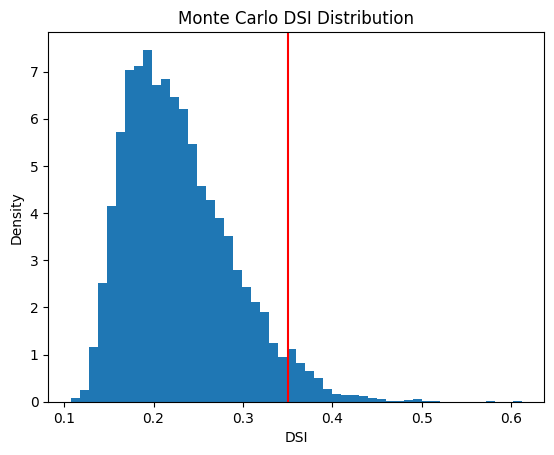

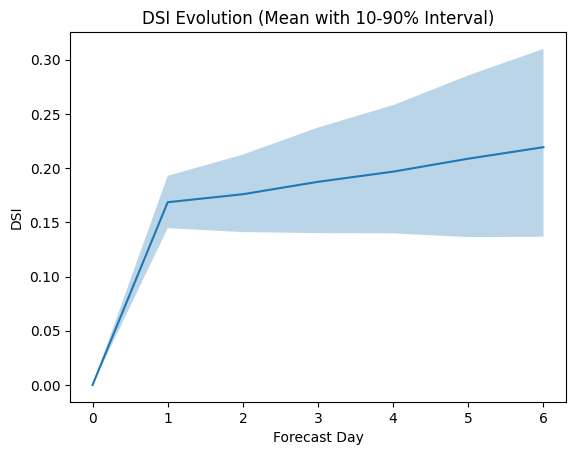

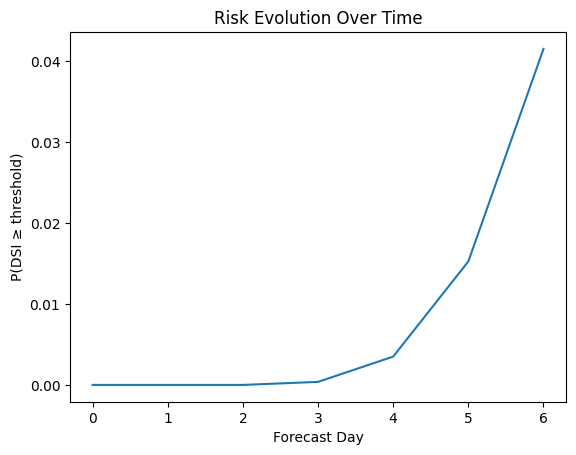

In [17]:
plt.figure()
plt.hist(dsi_mc, bins=50, density=True)
plt.axvline(threshold, color="red" )
plt.xlabel("DSI")
plt.ylabel("Density")
plt.title("Monte Carlo DSI Distribution")
plt.show()


mean_dsi = dsi_paths.mean(axis=0)
p10_dsi = np.percentile(dsi_paths, 10, axis=0)
p90_dsi = np.percentile(dsi_paths, 90, axis=0)

plt.figure()
plt.plot(mean_dsi)
plt.fill_between(range(len(mean_dsi)), p10_dsi, p90_dsi, alpha=0.3)
plt.xlabel("Forecast Day")
plt.ylabel("DSI")
plt.title("DSI Evolution (Mean with 10-90% Interval)")
plt.show()

prob_over_time = np.mean(dsi_paths >= threshold, axis=0)

plt.figure()
plt.plot(prob_over_time)
plt.xlabel("Forecast Day")
plt.ylabel("P(DSI ≥ threshold)")
plt.title("Risk Evolution Over Time")
plt.show()

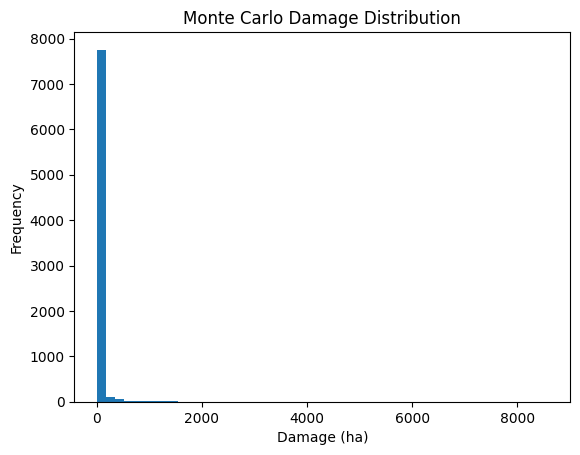

In [18]:
plt.figure()
plt.hist(damage_mc, bins=50)
plt.xlabel("Damage (ha)")
plt.ylabel("Frequency")
plt.title("Monte Carlo Damage Distribution")
plt.show()

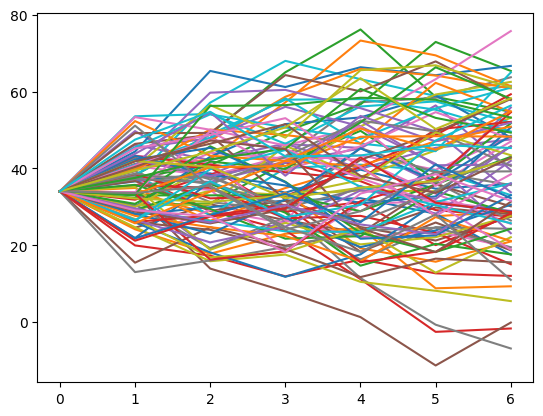

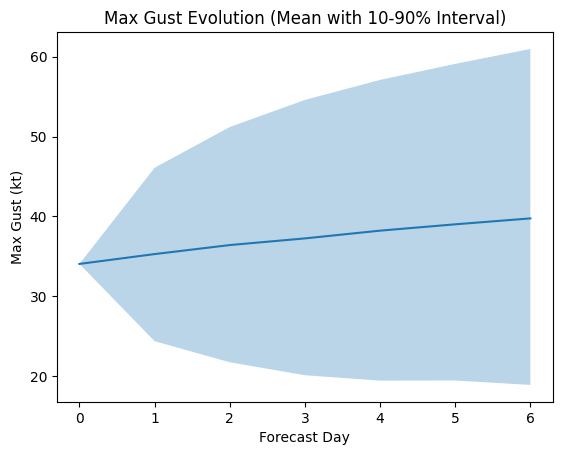

In [19]:
gust_paths = simulated["Max Gust (kt)"] 
for i in np.random.choice(range(gust_paths.shape[0]), 100, replace=False): 
    plt.plot(gust_paths[i])



mean_gust = gust_paths.mean(axis=0)
p10_gust = np.percentile(gust_paths, 10, axis=0)
p90_gust = np.percentile(gust_paths, 90, axis=0)

plt.figure()
plt.plot(mean_gust)
plt.fill_between(range(len(mean_gust)), p10_gust, p90_gust, alpha=0.3)
plt.xlabel("Forecast Day")
plt.ylabel("Max Gust (kt)")
plt.title("Max Gust Evolution (Mean with 10-90% Interval)")
plt.show()

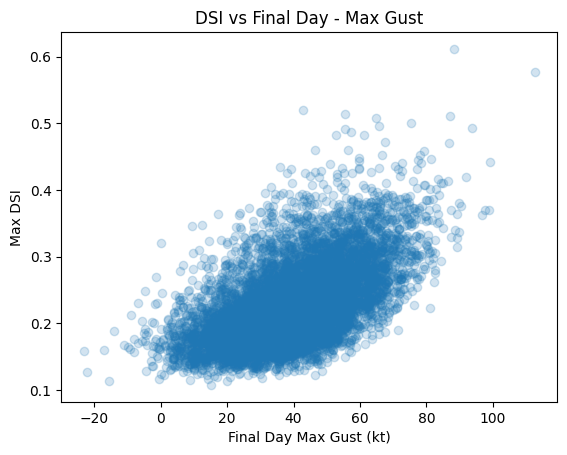

Corrolation r: 0.5742


In [20]:
final_gust = gust_paths[:, -1]

plt.figure()
plt.scatter(final_gust, dsi_mc, alpha=0.2)
plt.xlabel("Final Day Max Gust (kt)")
plt.ylabel("Max DSI")
plt.title("DSI vs Final Day - Max Gust")
plt.show()

r = np.corrcoef(final_gust, dsi_mc)[0, 1]
print(f"Corrolation r: {r:.4f}")

In [21]:
data = {
    "Gust": simulated["Max Gust (kt)"][:, -1],
    "Mean Wind": simulated["Mean Wind Speed (kt)"][:, -1],
    "Rain": simulated["Rain (mm)"][:, -1],
    "Temp": simulated["Max Temp (C)"][:, -1],
    "DSI": dsi_mc
}

df = pd.DataFrame(data)
print("Correlation Matrix:")
print(df.corr().round(3))

Correlation Matrix:
            Gust  Mean Wind   Rain   Temp    DSI
Gust       1.000      0.001 -0.001 -0.009  0.574
Mean Wind  0.001      1.000  0.010 -0.000  0.314
Rain      -0.001      0.010  1.000 -0.008  0.400
Temp      -0.009     -0.000 -0.008  1.000  0.006
DSI        0.574      0.314  0.400  0.006  1.000


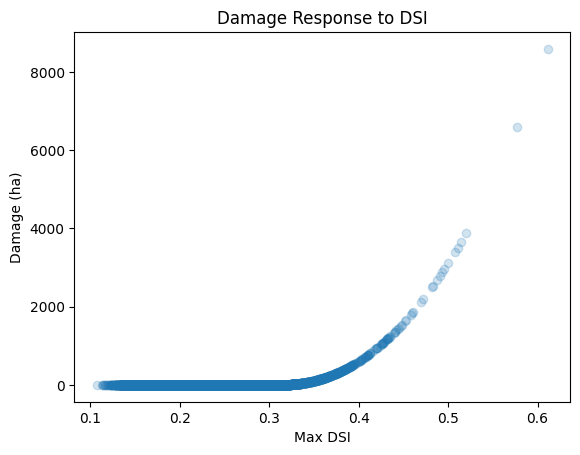

In [22]:
plt.figure()
plt.scatter(dsi_mc, damage_mc, alpha=0.2)
plt.xlabel("Max DSI")
plt.ylabel("Damage (ha)")
plt.title("Damage Response to DSI")
plt.show()

In [26]:
# ==========================================================
# Feedback mechanism
# ==========================================================

# Notification (Had to look up how to do this!)

import subprocess

def notify(title, message, image_path=None, sound="default"):
    cmd = [
        "terminal-notifier",
        "-title", title,
        "-message", message,
        "-sound", sound
    ]

    if image_path:
        cmd += ["-contentImage", image_path] 

    try:
        subprocess.run(cmd)
    except e:
        print("Error sending notifcation", e)

if prob < 0.25:
    level = "🛡 Low storm risk"
    sound = "Ping"

elif prob < 0.60:
    level = "⚠️ HIGH STORM RISK"
    sound = "Hero"

else:
    level = "🚨 EXTREME STORM RISK"
    sound = "Submarine"

notify(
    level,
    f"Probability: {prob*100:.2f}%",
    image_path="/Users/lukaslydn/Desktop/LCCS project/Model/download.png",
    sound=sound
)